<a href="https://colab.research.google.com/github/saim9211/Machine-Learning-Stuff/blob/main/Decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
import kagglehub
path = kagglehub.dataset_download("uciml/red-wine-quality-cortez-et-al-2009")

Using Colab cache for faster access to the 'red-wine-quality-cortez-et-al-2009' dataset.


In [36]:
import pandas as pd

df = pd.read_csv(f'{path}/winequality-red.csv')
display(df.sample(3))

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
696,7.0,0.650,0.02,2.10,0.066,8.0,25.0,0.99720,3.47,0.67,9.5,6
914,7.3,0.305,0.39,1.20,0.059,7.0,11.0,0.99331,3.29,0.52,11.5,6
357,10.5,0.420,0.66,2.95,0.116,12.0,29.0,0.99700,3.24,0.75,11.7,7


In [37]:
df['quality']

,quality
0,5
1,5
2,5
3,6
4,5
...,...
1594,5
1595,6
1596,6
1597,5


In [38]:
import numpy as np
import matplotlib as plt
import seaborn as sns

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [60]:
columns_to_drop = ['fixed acidity', 'citric acid', 'chlorides', 'residual sugar', 'density']
df = df.drop(columns=columns_to_drop)
display(df.head())

,volatile acidity,free sulfur dioxide,total sulfur dioxide,pH,sulphates,alcohol,quality
0,0.70,11.0,34.0,3.51,0.56,9.4,5
1,0.88,25.0,67.0,3.20,0.68,9.8,5
2,0.76,15.0,54.0,3.26,0.65,9.8,5
3,0.28,17.0,60.0,3.16,0.58,9.8,6
4,0.70,11.0,34.0,3.51,0.56,9.4,5


In [61]:
df.isnull().sum()

,0
volatile acidity,0
free sulfur dioxide,0
total sulfur dioxide,0
pH,0
sulphates,0
alcohol,0
quality,0


In [41]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


In [42]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [62]:
x_train, x_test, y_train, y_test = train_test_split(df.drop('quality', axis=1), df['quality'], test_size=0.2, random_state=42)

In [44]:
x_test.shape, x_train.shape, y_test.shape, y_train.shape

((1279, 11), (320, 11), (1279,), (320,))

In [53]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor # Changed from DecisionTreeClassifier

# Define the base pipeline with a scaler and a Decision Tree Regressor
base_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', DecisionTreeRegressor(random_state=42)) # Changed to regressor
])

# Define the parameter grid for the DecisionTreeRegressor
param_grid = {
    'regressor__max_depth': [3, 5, 7, None],  # None means no limit
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4],
    'regressor__criterion': ['squared_error', 'friedman_mse', 'absolute_error'] # Regression criteria
}

# Create a GridSearchCV object that wraps the pipeline
# The 'pipeline' variable will now hold the GridSearchCV object
pipeline = GridSearchCV(estimator=base_pipeline,
                        param_grid=param_grid,
                        cv=5, # 5-fold cross-validation
                        scoring='neg_mean_squared_error', # Changed to a regression metric
                        n_jobs=-1, # Use all available cores
                        verbose=1) # Display progress

In [63]:
pipeline.fit(x_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('regressor',
                                        DecisionTreeRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'regressor__criterion': ['squared_error',
                                                  'friedman_mse',
                                                  'absolute_error'],
                         'regressor__max_depth': [3, 5, 7, None],
                         'regressor__min_samples_leaf': [1, 2, 4],
                         'regressor__min_samples_split': [2, 5, 10]},
             scoring='neg_mean_squared_error', verbose=1)

In [64]:
print("Best Parameters found (after feature removal):", pipeline.best_params_)
print("Best Cross-Validation Score (Negative MSE, after feature removal):", pipeline.best_score_)

Best Parameters found (after feature removal): {'regressor__criterion': 'squared_error', 'regressor__max_depth': 5, 'regressor__min_samples_leaf': 4, 'regressor__min_samples_split': 2}
Best Cross-Validation Score (Negative MSE, after feature removal): -0.4679026337146919


In [65]:
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report
import numpy as np

# Evaluate the model with the best estimator (regressor)
y_pred_tuned = pipeline.best_estimator_.predict(x_test)

# Round predictions to nearest integer for interpretation as quality scores, if desired
y_pred_tuned_rounded = np.round(y_pred_tuned).astype(int)

print("Mean Squared Error (tuned model, after feature removal):", mean_squared_error(y_test, y_pred_tuned))
print("R-squared (tuned model, after feature removal):", r2_score(y_test, y_pred_tuned))

# If you still want to see 'accuracy' in terms of rounded predictions vs actual classes
# This is not a standard regression metric, but can be informative for discrete targets
print("\nAccuracy Score (rounded predictions vs actual, tuned model, after feature removal):", accuracy_score(y_test, np.clip(y_pred_tuned_rounded, y_test.min(), y_test.max())))
print("\nConfusion Matrix (rounded predictions, tuned model, after feature removal):\n", confusion_matrix(y_test, np.clip(y_pred_tuned_rounded, y_test.min(), y_test.max())))
print("\nClassification Report (rounded predictions, tuned model, after feature removal):\n", classification_report(y_test, np.clip(y_pred_tuned_rounded, y_test.min(), y_test.max())))


Mean Squared Error (tuned model, after feature removal): 0.41973281667286527
R-squared (tuned model, after feature removal): 0.35772141802326096

Accuracy Score (rounded predictions vs actual, tuned model, after feature removal): 0.5625

Confusion Matrix (rounded predictions, tuned model, after feature removal):
 [[ 0  0  0  1  0  0]
 [ 0  1  4  5  0  0]
 [ 0  2 80 48  0  0]
 [ 0  0 36 91  5  0]
 [ 0  0  1 33  8  0]
 [ 0  0  0  3  2  0]]

Classification Report (rounded predictions, tuned model, after feature removal):
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.33      0.10      0.15        10
           5       0.66      0.62      0.64       130
           6       0.50      0.69      0.58       132
           7       0.53      0.19      0.28        42
           8       0.00      0.00      0.00         5

    accuracy                           0.56       320
   macro avg       0.34      0.27      0.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


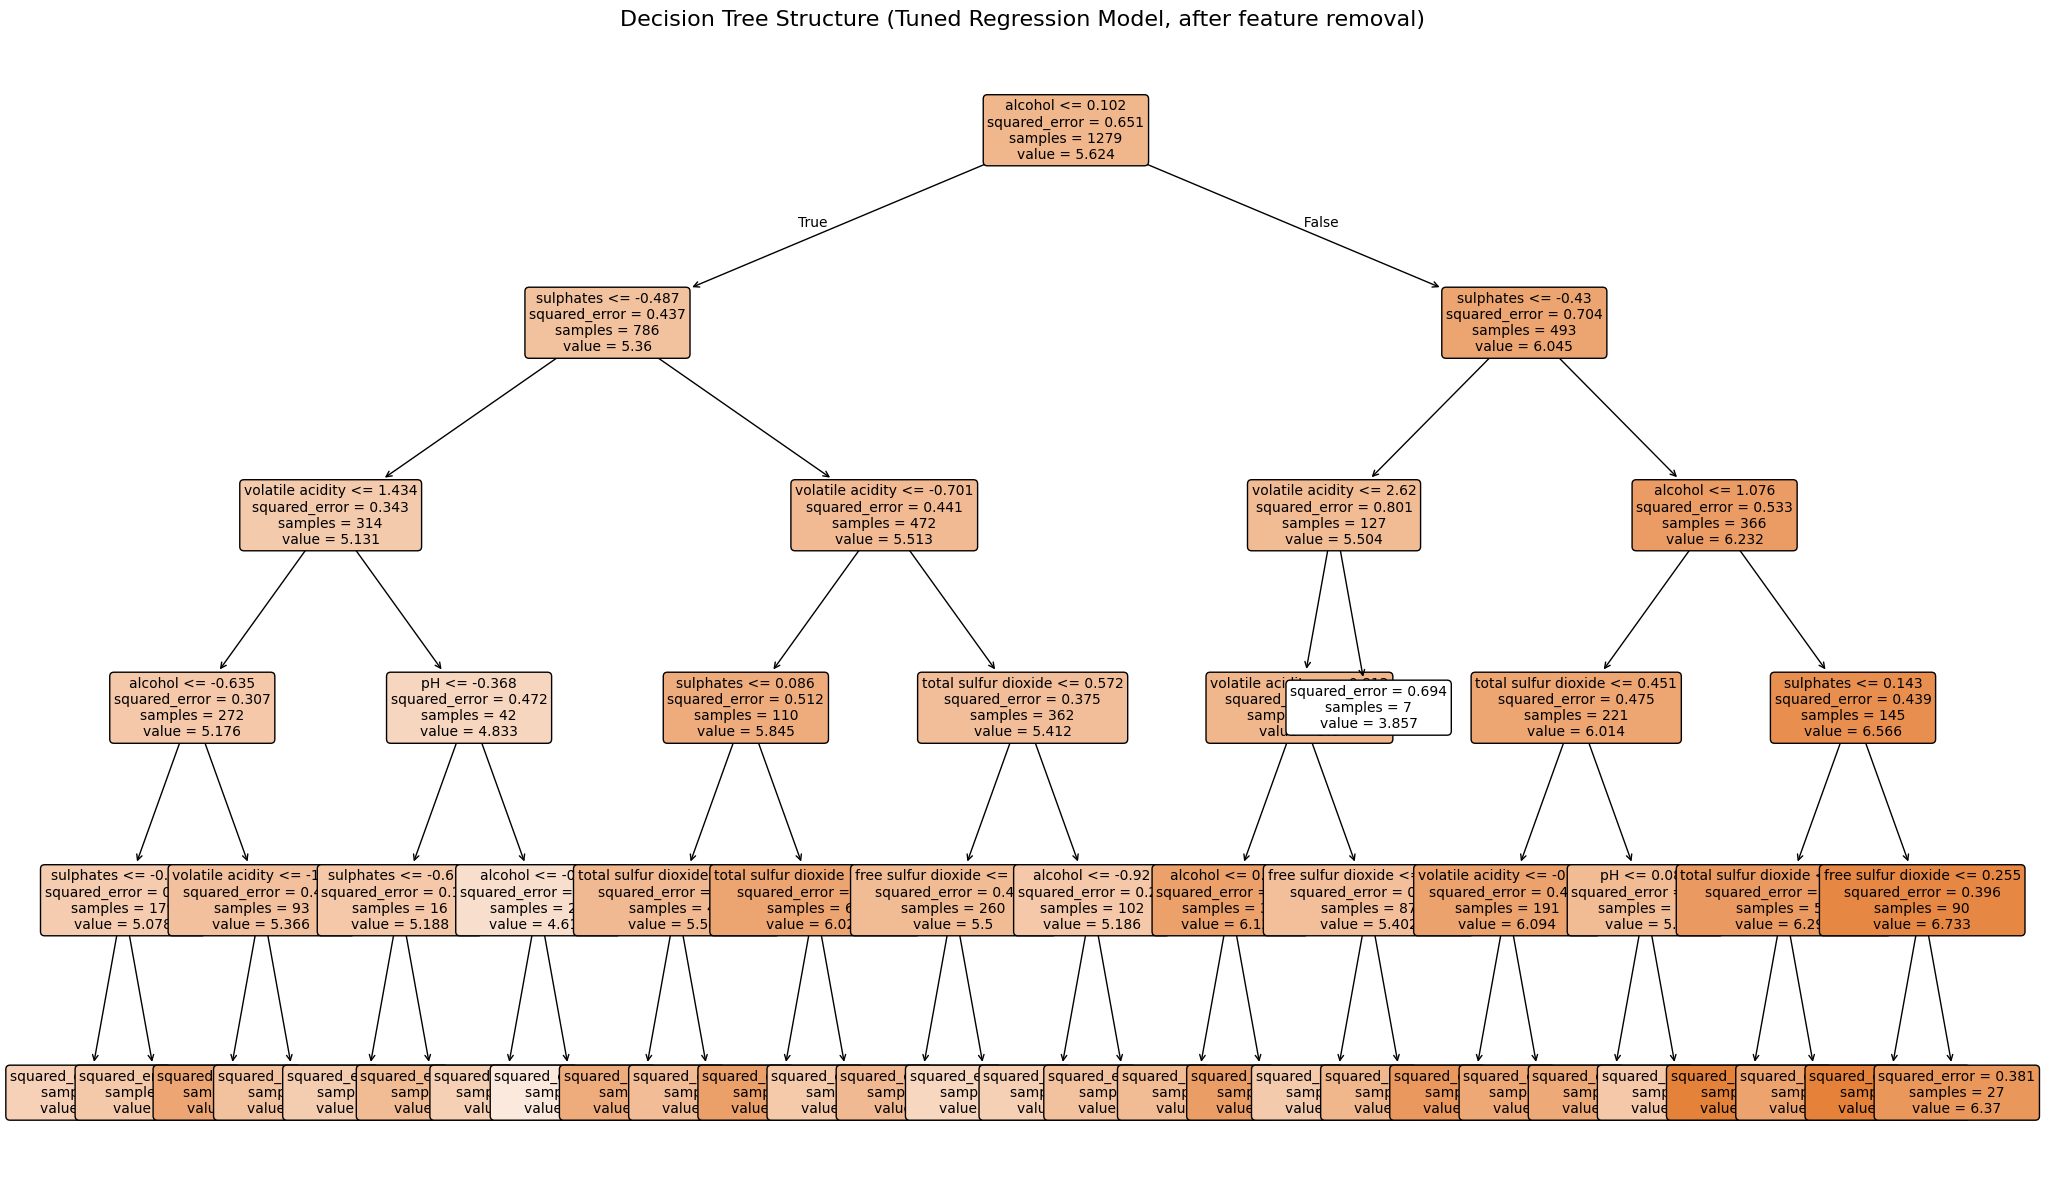

In [67]:
import matplotlib.pyplot as plt

# Get the best DecisionTreeRegressor from the pipeline
best_tree_model = pipeline.best_estimator_.named_steps['regressor']

# Get feature names from x_train (updated after column removal)
feature_names = x_train.columns.tolist()

# Get class names from y_train (unique quality levels) - still useful for visualization as 'value' display
class_names = [str(int(c)) for c in sorted(y_train.unique())]

plt.figure(figsize=(25, 15))
plot_tree(best_tree_model,
          feature_names=feature_names,
          class_names=class_names, # Use for class display in nodes, even for regression
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Decision Tree Structure (Tuned Regression Model, after feature removal)', fontsize=16)
plt.show()

/tmp/ipykernel_621/1031953914.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')


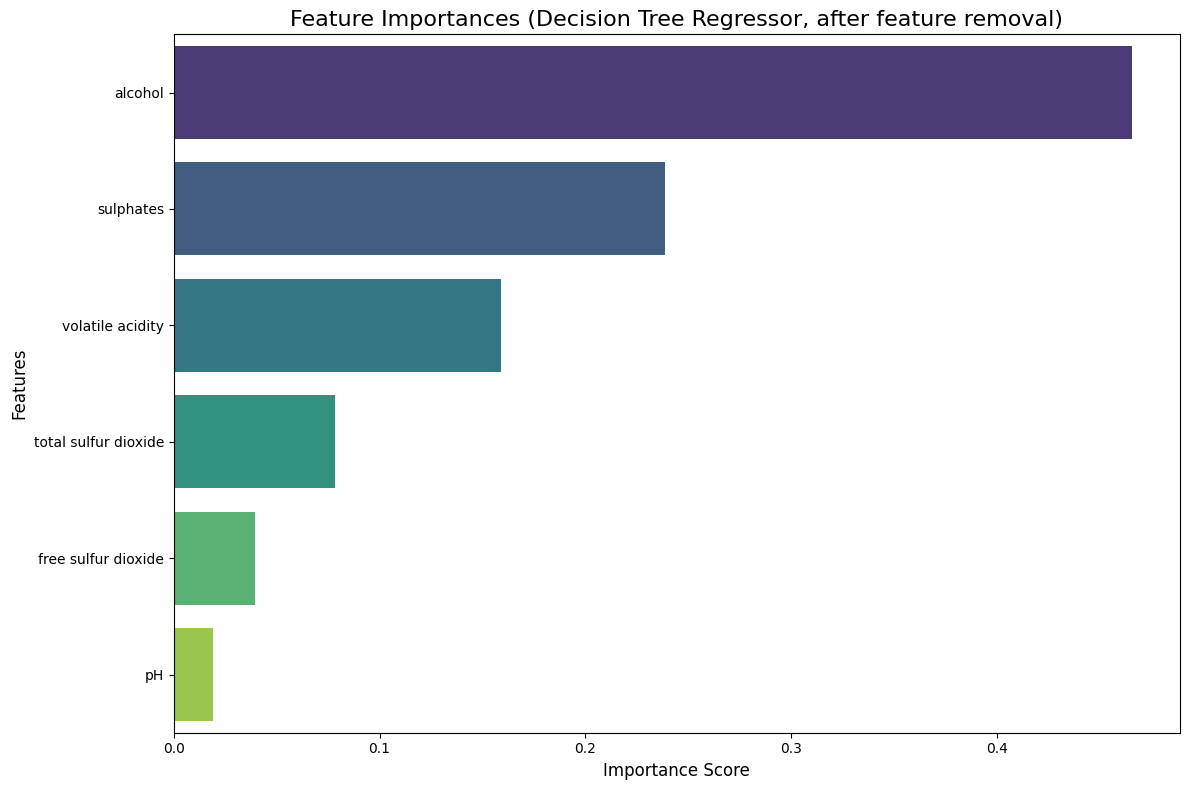

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the best DecisionTreeRegressor from the pipeline
best_regressor = pipeline.best_estimator_.named_steps['regressor']

# Get feature importances
importances = best_regressor.feature_importances_

# Create a pandas Series for better visualization, using updated x_train.columns
feature_importances = pd.Series(importances, index=x_train.columns).sort_values(ascending=False)

# Plotting the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')
plt.title('Feature Importances (Decision Tree Regressor, after feature removal)', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

In [70]:
from sklearn.metrics import mean_squared_error, r2_score

# Predicting using the *tuned* regressor after feature removal
y_pred_regressor = pipeline.best_estimator_.predict(x_test)

print("Mean Squared Error (tuned regressor, after feature removal):", mean_squared_error(y_test, y_pred_regressor))
print("R-squared (tuned regressor, after feature removal):", r2_score(y_test, y_pred_regressor))

Mean Squared Error (tuned regressor, after feature removal): 0.41973281667286527
R-squared (tuned regressor, after feature removal): 0.35772141802326096


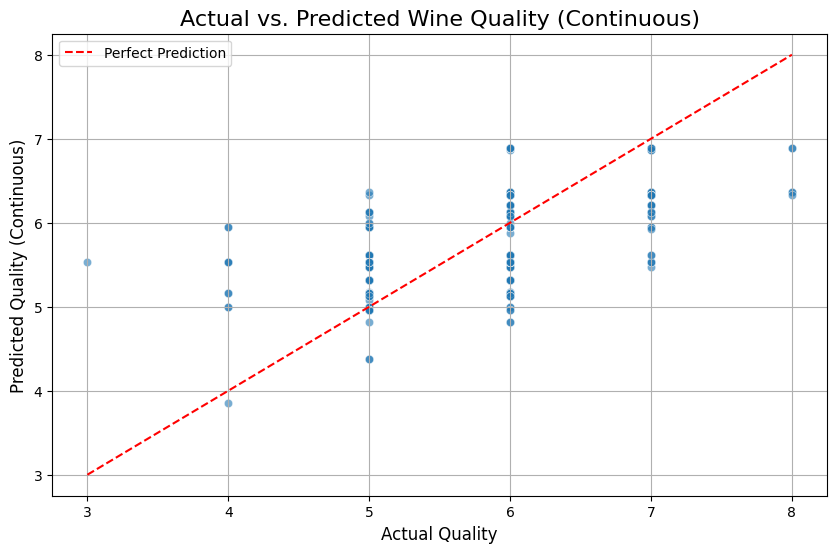

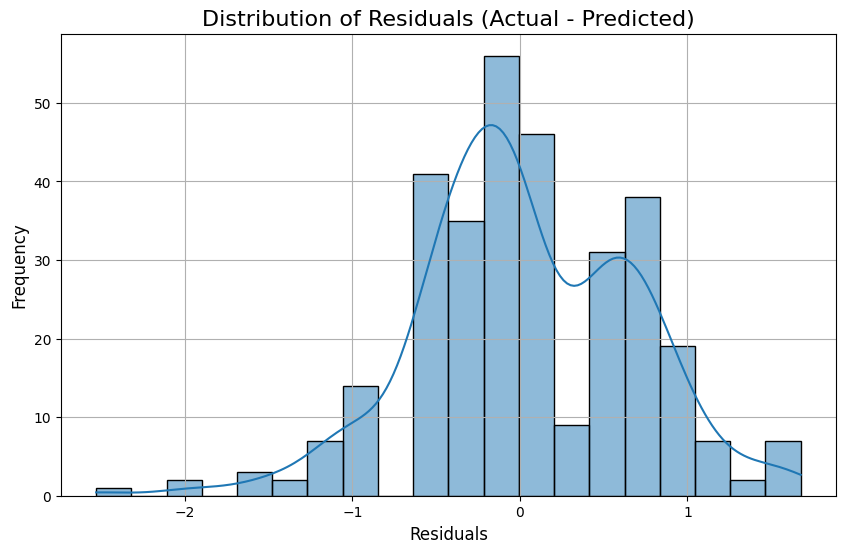

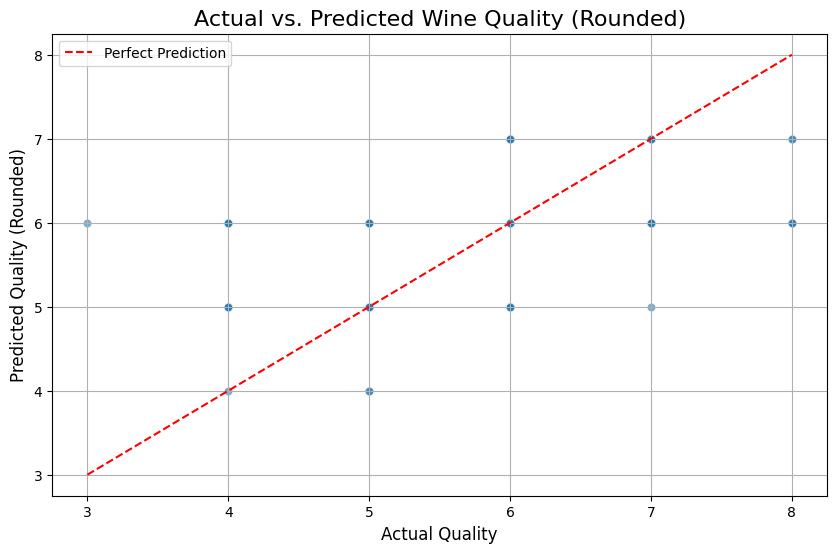

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for easier plotting
results_df = pd.DataFrame({'Actual Quality': y_test, 'Predicted Quality (Continuous)': y_pred_tuned, 'Predicted Quality (Rounded)': y_pred_tuned_rounded})

# --- Scatter plot of Actual vs. Predicted (Continuous) ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Actual Quality', y='Predicted Quality (Continuous)', data=results_df, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', label='Perfect Prediction') # Perfect prediction line
plt.title('Actual vs. Predicted Wine Quality (Continuous)', fontsize=16)
plt.xlabel('Actual Quality', fontsize=12)
plt.ylabel('Predicted Quality (Continuous)', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

# --- Distribution of Residuals (Errors) ---
residuals = y_test - y_pred_tuned
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=20)
plt.title('Distribution of Residuals (Actual - Predicted)', fontsize=16)
plt.xlabel('Residuals', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True)
plt.show()

# --- Scatter plot of Actual vs. Predicted (Rounded) ---
# This helps to visualize how many rounded predictions match actual values
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Actual Quality', y='Predicted Quality (Rounded)', data=results_df, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', label='Perfect Prediction') # Perfect prediction line
plt.title('Actual vs. Predicted Wine Quality (Rounded)', fontsize=16)
plt.xlabel('Actual Quality', fontsize=12)
plt.ylabel('Predicted Quality (Rounded)', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()